# t-SNE

- 비선형 차원 축소 기법으로 고차원의 데이터를 국소 구조를 보존하면서 2차원 또는 3차원 시각화 하기 위해 주로 사용
- 고차원의 경우에는 거리 기반의 유사도 (가우시안 분포를 이용한 계산)
- 저차원의 경우에는 확률적으로 비슷하게 재현(t-분포를 이용한 계산)
    - t-분포를 사용하는 이유는 멀리 떨어진 점간의 거리 차이를 완화시키기 위한 방법

### 거리 계산 방식
- 유클리드 거리(euclidean) -> 기본적인 거리 방식 (직선 거리)
- 맨헤튼 거리 (manhattan) -> 직각 축 기반 거리
- 체비쇼프 거리 (chebyshev) -> 최대의 축 차이 기반
- 코사인 거리 (cosine) -> 벡터 방향 기반
- 마할라노비스 거리(mahalanobis) -> 변수 간 상관 반영
- 해밍 거리(hamming) -> 이진 데이터 전용

- 매개변수
    - n_components
        - 기본값 : 2
        - 축소할 차원의 개수
    - preplexity
        - 기본값 : 30
        - 이웃의 수 제어 (군집 크기 민감)
        - 보통 5 - 50정도의 값
        - 값이 작은 경우는 작은 구조, 큰 경우에는 전체 구조
        - 일반적으로는 샘플의 개수 / 3
        - 너무 큰 값을 생성하면 전체를 포괄하는 형태가 될 수 있음
    - early_exggerarion
        - 기본값 : 12
        - 초기 학습에서 군집 간의 거리를 지정 (분리 촉진)
    - learning_rate
        - 기본값 : 'auto'
        - 학습의 속도
        - 너무 작게 지정하면 수렴 느려짐
        - 너무 크게 하는 경우에는 군집이 왜곡
        - 100~1000 정도의 값을 사용
    - max_iter
        - 기본값 : 1000
        - 전체 학습 반복 횟수
    - n_iter_without_progress
        - 기본값 : 300
        - 개선이 없을 때 조기 종료 기준
    - init
        - 기본값 : 'pca'
        - 초기 좌표를 설정하는 방법
        - random을 사옹 시 좌표를 무작위로 선택
    - metric
        - 기본값 : 'euclidean'
        - 거리 계산 방식
    - method
        - 기본값 : 'barnes_hut'
        - 기본값을 사용 시 빠른 속도로 계산
        - 'exact'는 정확하지만 시간은 증가
    - angle
        - 기본값 : 0.5
        - barnes_hut 근사 정확도를 제어
        - 작을수록 정확하고 느림

- 속성
    - embedding_
        - 변환된 저차원 데이터 반환
    - kl_divergence_
        - 최종 KL 발산 값 반환(작을수록 원래의 구조와 유사)
- 메서드
    - fit()
        - 모델에 데이터를 학습
    - transform()
        - 데이터를 저차원 변환
    - fit_transform()
        - 데이터를 학습하고 저차원 데이터로 변환

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

In [2]:
# 데이터셋 로드
digits = load_digits()

In [3]:
digits

{'data': array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ..., 10.,  0.,  0.],
        [ 0.,  0.,  0., ..., 16.,  9.,  0.],
        ...,
        [ 0.,  0.,  1., ...,  6.,  0.,  0.],
        [ 0.,  0.,  2., ..., 12.,  0.,  0.],
        [ 0.,  0., 10., ..., 12.,  1.,  0.]], shape=(1797, 64)),
 'target': array([0, 1, 2, ..., 8, 9, 8], shape=(1797,)),
 'frame': None,
 'feature_names': ['pixel_0_0',
  'pixel_0_1',
  'pixel_0_2',
  'pixel_0_3',
  'pixel_0_4',
  'pixel_0_5',
  'pixel_0_6',
  'pixel_0_7',
  'pixel_1_0',
  'pixel_1_1',
  'pixel_1_2',
  'pixel_1_3',
  'pixel_1_4',
  'pixel_1_5',
  'pixel_1_6',
  'pixel_1_7',
  'pixel_2_0',
  'pixel_2_1',
  'pixel_2_2',
  'pixel_2_3',
  'pixel_2_4',
  'pixel_2_5',
  'pixel_2_6',
  'pixel_2_7',
  'pixel_3_0',
  'pixel_3_1',
  'pixel_3_2',
  'pixel_3_3',
  'pixel_3_4',
  'pixel_3_5',
  'pixel_3_6',
  'pixel_3_7',
  'pixel_4_0',
  'pixel_4_1',
  'pixel_4_2',
  'pixel_4_3',
  'pixel_4_4',
  'pixel_4_5',
  'pixel_4_6',
  'pixel_4_7'

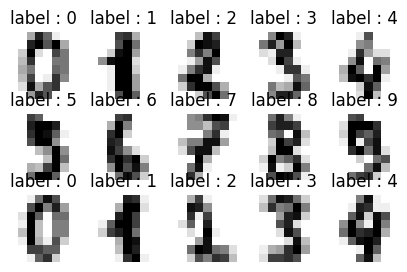

In [7]:
plt.figure(figsize=(5, 3))

for i in range(15) :
    plt.subplot(3, 5, i+1)
    plt.imshow(digits.images[i], cmap='gray_r')
    plt.title(f'label : {digits.target[i]}')
    plt.axis('off')

plt.show()

In [8]:
# 데이터를 스케일링
X = StandardScaler().fit_transform(digits['data'])
Y = digits['target']

In [10]:
# 차원 축소 class 생성
tsne = TSNE(
    n_components = 2,
    perplexity = 40,
    learning_rate = 'auto',
    random_state = 42,
    n_jobs = -1  # 멀티코어 전체 사용
)
X_tsne = tsne.fit_transform(X)

In [11]:
X.shape

(1797, 64)

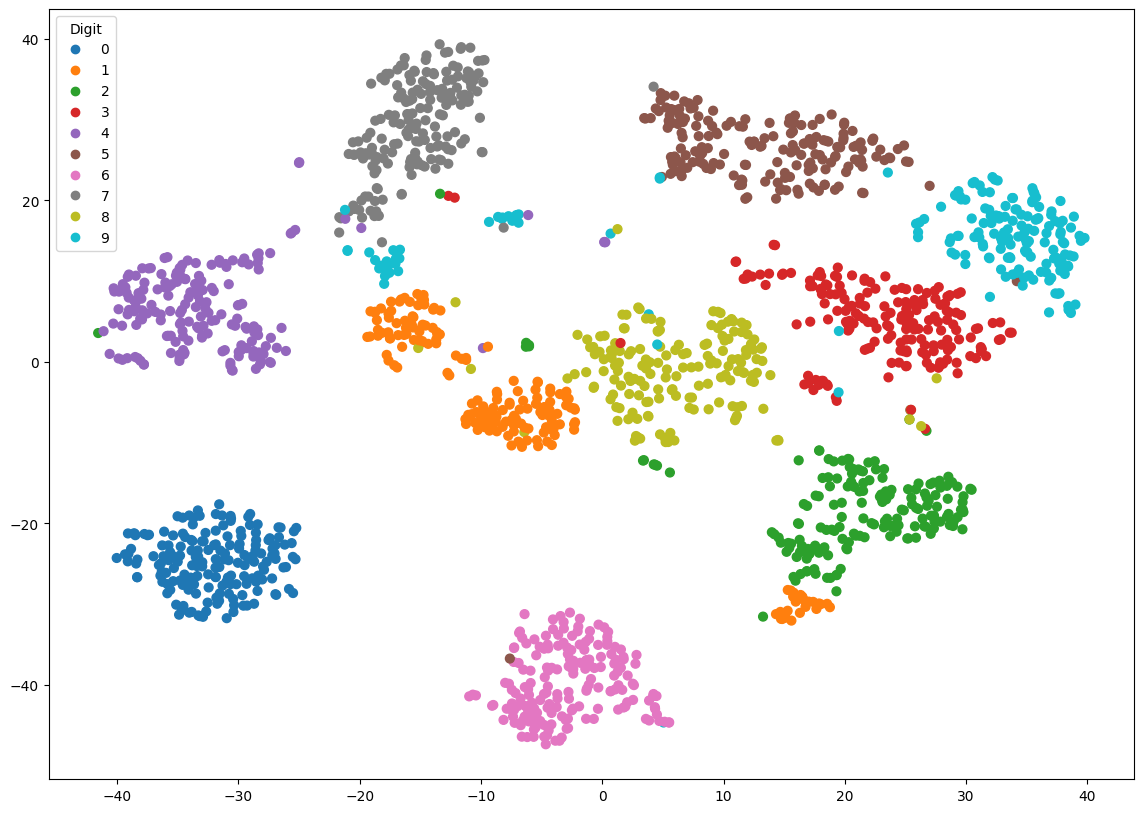

In [12]:
# 64차원의 데이터를 2차원으로 변경하고 데이터의 분류를 그래프로 시각화
plt.figure(figsize=(14, 10))
sc = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c = Y, cmap = 'tab10', s = 40)
plt.legend(*sc.legend_elements(), title="Digit")
plt.show()

In [13]:
print("KL divergence :", round(tsne.kl_divergence_, 4))
print('Iteration :', tsne.n_iter_)

KL divergence : 0.801
Iteration : 999


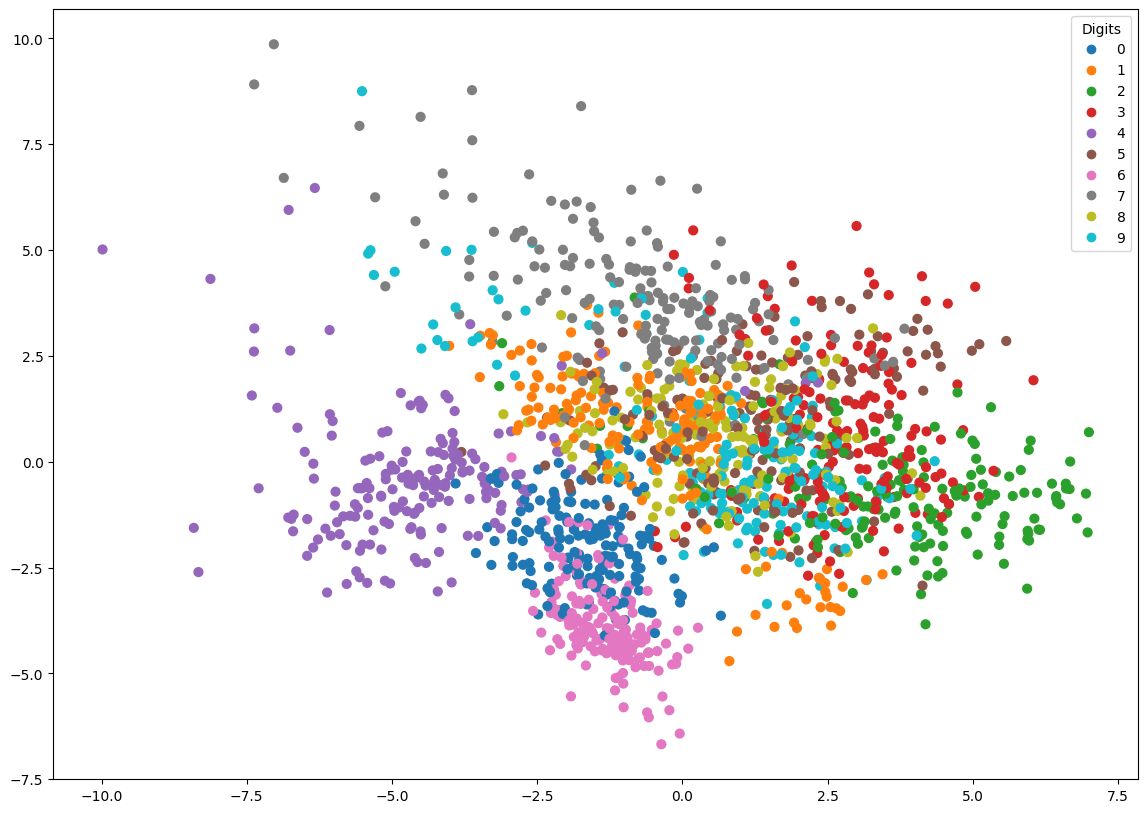

In [15]:
# PCA로 2차원 데이터 시각화
from sklearn.decomposition import PCA

pca = PCA(n_components = 2)
X_pca = pca.fit_transform(X)

# 시각화
plt.figure(figsize=(14, 10))
sc = plt.scatter(X_pca[:, 0], X_pca[:, 1], c = Y, cmap='tab10', s = 40)
plt.legend(*sc.legend_elements(), title='Digits')
plt.show()

In [16]:
from sklearn.datasets import make_moons

In [17]:
# 반월 모양의 데이터셋을 생성
X, Y = make_moons(n_samples = 1000, noise = 0.1, random_state = 42)
X_std = StandardScaler().fit_transform(X)

In [19]:
X_std.shape

(1000, 2)

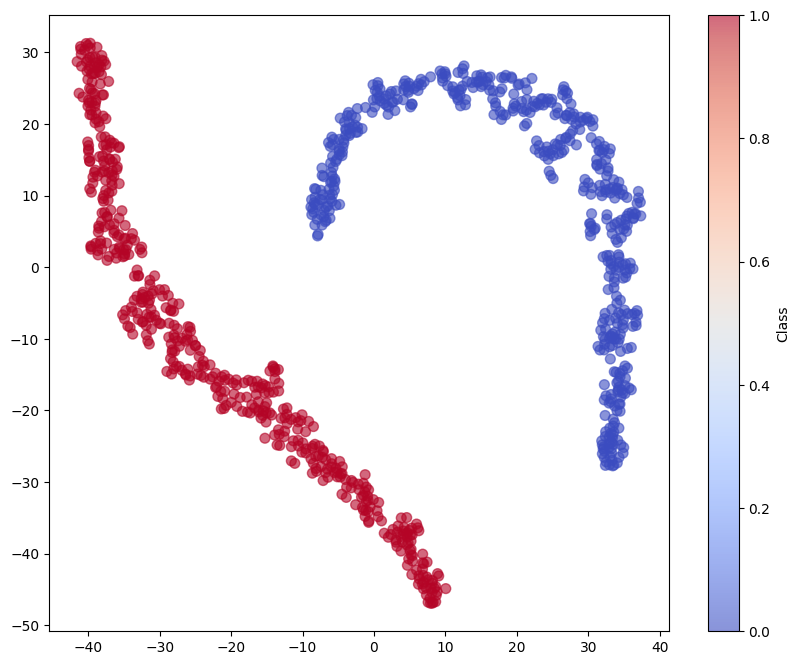

In [22]:
# T_SNE을 적용해서 2차원 데이터로 구성
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, random_state=42)
X_tsne = tsne.fit_transform(X_std)

plt.figure(figsize=(10, 8))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c = Y, cmap='coolwarm', s = 50, alpha = 0.6)

plt.colorbar(label='Class')
plt.show()

In [24]:
# bodyPerformance 데이터를 이용하여 tsne 차원축소
import pandas as pd
from sklearn.preprocessing import LabelEncoder

In [26]:
body = pd.read_csv("../data/bodyPerformance.csv")

In [27]:
# dtypes가 'object'인 컬럼을 모두 선택해서 LabelEncoder 변환

# dtypes가 'object'인 컬럼의 목록 확인
obj_list = body.select_dtypes('object').columns.tolist()
obj_list

['gender', 'class']

In [28]:
for col in obj_list:
    le = LabelEncoder()
    body[col] = le.fit_transform(body[col].values)

body.head()

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27.0,1,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,2
1,25.0,1,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,0
2,31.0,1,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,2
3,32.0,1,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,1
4,28.0,1,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,1


In [29]:
# 고차원 데이터에서는 PCA를 통해서 차원 축소(30~50차원)를 1차적으로 진행한 뒤 t-SNE를 이용하여 2차 작업 -> t-SNE의 안정성과 속도 향상
X = body.drop('class', axis=1).values
Y = body['class'].values
# X를 스케일링
X_std = StandardScaler().fit_transform(X)

# PCA를 통해서 1차 차원 축소
X_pca = PCA(
    n_components=min(30, X_std.shape[1]),
    random_state=42
).fit_transform(X_std)

In [31]:
X_pca.shape

(13393, 11)

In [32]:
# t-SNE를 이용하여 2차 차원 축소
tsne = TSNE(
    n_components=2,
    perplexity=40,
    random_state=42
)
X_tsne = tsne.fit_transform(X_pca)

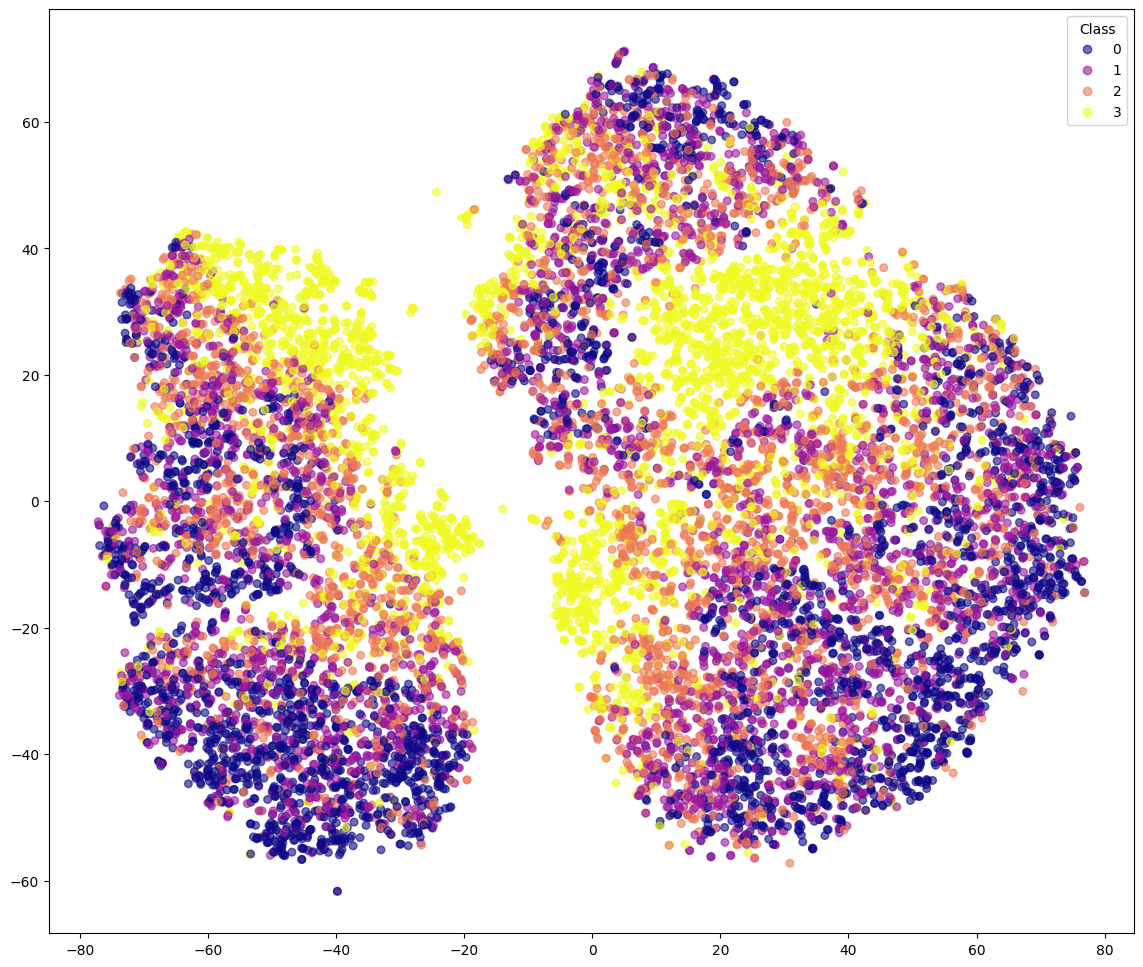

In [34]:
# 클래스를 기준으로 데이터를 시각화
plt.figure(figsize=(14,12))
sc = plt.scatter(
    X_tsne[:, 0], X_tsne[:, 1],
    c = Y, cmap='plasma', s=30, alpha=0.6
)
plt.legend(*sc.legend_elements(), title='Class')

plt.show()

In [35]:
# 샘플 고차원 데이터를 생성
from sklearn.datasets import make_blobs

In [56]:
# 3개의 군집 데이터를 고차우너 데이터로 생성
X, Y = make_blobs(n_samples=1500, centers=3, n_features=80, cluster_std=3, random_state=42)

In [57]:
X.shape

(1500, 80)

In [58]:
# 스케일링 작업
X_std = StandardScaler().fit_transform(X)

In [59]:
import time

KL divergence : 1.8624
실행 시간 : 6.6715


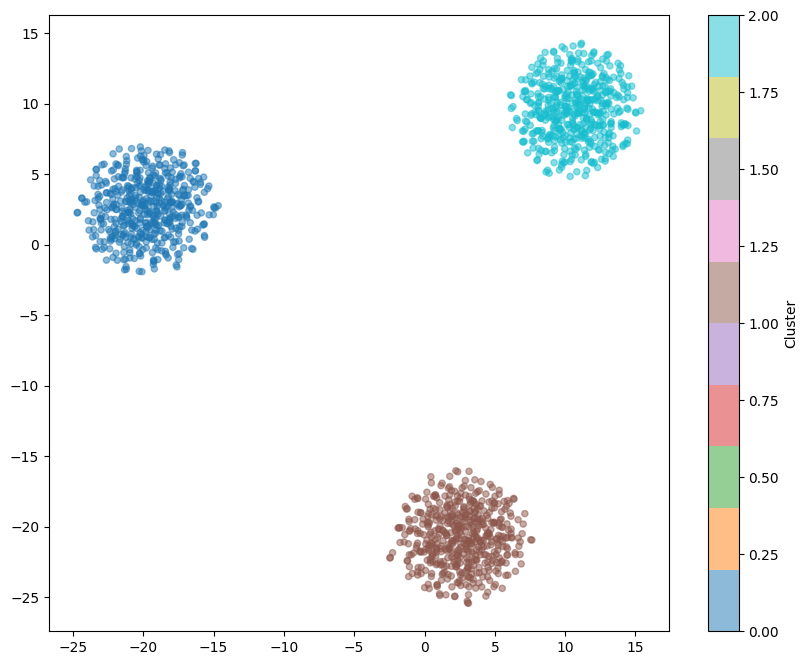

In [60]:
# 시작 시간을 입력
start = time.time()
# t-SNE만을 사용해서 2차원 차원 축소
tsne = TSNE(
    n_components=2,
    perplexity=40,
    random_state=42
)

X_tsne = tsne.fit_transform(X_std)
# 종료 시간을 입력
end = time.time()
# KL_divergence 값 확인 -> 고차원과 저차원 확률 분포의 차이 (작을수록 좋음)
print("KL divergence :", round(tsne.kl_divergence_, 4))
# 총 실행 시간을 출력
print('실행 시간 :', round((end-start), 4))
plt.figure(figsize=(10, 8))
plt.scatter(
    X_tsne[:, 0], X_tsne[:, 1], c = Y, cmap='tab10', s=20, alpha=0.5
)
plt.colorbar(label='Cluster')
plt.show()

In [61]:
# PCA + t-SNE을 사용하여 차원 축소 실행
# PCA를 이용하여 차원을 30으로 축소한 뒤 t-SNE를 사용

KL divergence : 1.7951
실행 시간 : 6.52


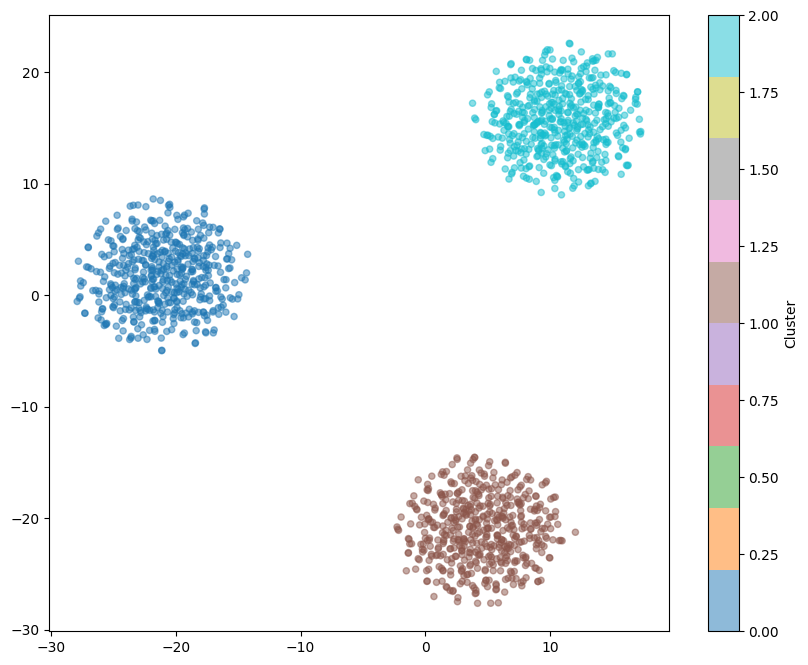

In [62]:
# 시작 시간을 입력
start = time.time()

X_pca = PCA(
    n_components=min(30, X_std.shape[1]),
    random_state=42
).fit_transform(X_std)

tsne = TSNE(
    n_components=2,
    perplexity=40,
    random_state=42
)
# pca를 이용한 차원 축소 데이터를 이용하여 tsne로 2차 차원 축소 진행
X_tsne = tsne.fit_transform(X_pca)
# 종료 시간을 입력
end = time.time()
# KL_divergence 값 확인 -> 고차원과 저차원 확률 분포의 차이 (작을수록 좋음)
print("KL divergence :", round(tsne.kl_divergence_, 4))
# 총 실행 시간을 출력
print('실행 시간 :', round((end-start), 4))
plt.figure(figsize=(10, 8))
plt.scatter(
    X_tsne[:, 0], X_tsne[:, 1], c = Y, cmap='tab10', s=20, alpha=0.5
)
plt.colorbar(label='Cluster')
plt.show()